In this code I am going to plot the refracted angle vs incident angle of different glass compositions. 

interactive(children=(IntSlider(value=0, description='i', max=825), Output()), _dom_classes=('widget-interact'…

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


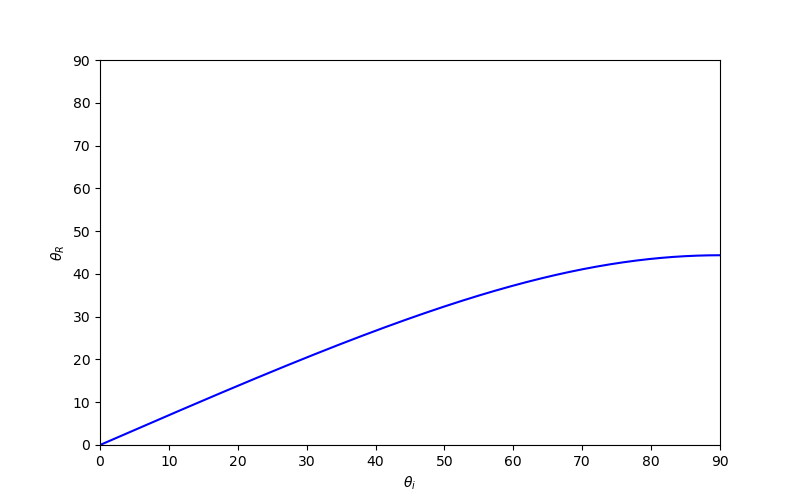

In [2]:
%matplotlib widget 

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd     

df = pd.read_excel("/Users/josephschellenberg/Downloads/Fresnell/Fresnell.xlsx")  # Or .csv with pd.read_csv

# Extract columns into arrays- this will be changed one i get exell file
wave_numbers = df["wave_numbers"].values
n0_array = df["n0"].values
k0_array = df["k0"].values
n1_array = df["n1"].values
k1_array = df["k1"].values



def cos(th):
    return np.cos(th*np.pi/180) 

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 

def sin(th):
    return np.sin(th*np.pi/180) 

# 3 Returns transmitted angle from incident angle
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))   


def RefractedAnglePlot(snells, wave_numbers, n0_array, k0_array, n1_array, k1_array):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    th0 = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((0,90))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel(r'$\theta_R$')
    #ax0.legend([r'rperptotal'],)
    def plot(i=0):
        wn = wave_numbers[i] 
        n0 = n0_array[i] 
        k0 = k0_array[i]
        n1 = n1_array[i]
        k1 = k1_array[i] 
        output1 = snells(n0, n1, k0, k1, th0)
        line01.set_data(th0, output1)
        plt.draw() 
        print(f"Wavenumber at index {i}: {wn}")
    interact(plot, i=(0, len(n0_array)-1)) 

RefractedAnglePlot(snells, wave_numbers, n0_array, k0_array, n1_array, k1_array)
